# Time inhomogeneity

In [1]:
from phasic import (Graph, with_ipv,
    StateIndexer, Property
) # ALWAYS import phasic first to set jax backend correctly
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from typing import Optional
from tqdm.auto import tqdm
from functools import partial
from vscodenb import set_vscode_theme, vscode_theme
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## Step-wise construction

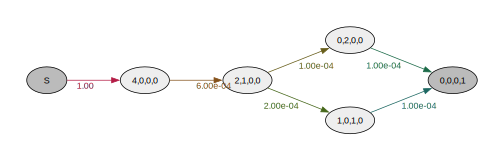

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
N = 10000
graph.update_weights([1/N])
graph.plot()

## PDF and CDF

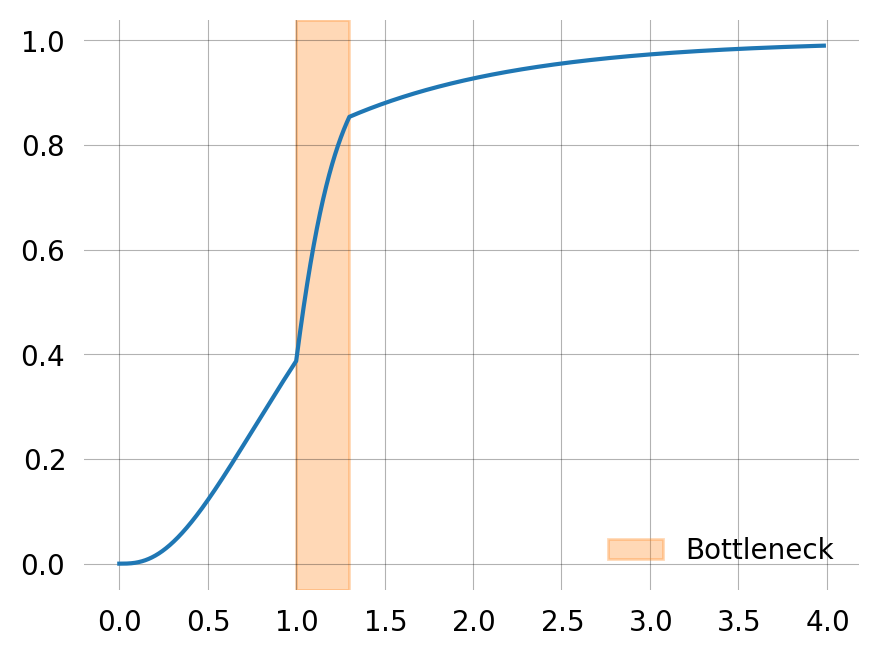

In [3]:
graph = Graph(coalescent_1param)

N = 1
N_bottle, t_start, t_end = 0.2, 1, 1.3

param_changes = [         
                 (t_start, [1/N_bottle]), 
                 (t_end,   [1/N])
                 ]

cdf_cutoff = 0.99
cdf = []
times = []
ctx = graph.distribution_context()
graph.update_weights([1/N])

for change_time, new_params in param_changes:
    while ctx.time() < change_time:
        cdf.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
        if ctx.cdf() >= cdf_cutoff:
            break
    graph.update_weights(new_params)
while ctx.cdf() < cdf_cutoff:
    cdf.append(ctx.cdf())
    times.append(ctx.time())
    ctx.step()

plt.plot(times, cdf)
plt.axvspan(xmin=t_start, xmax=t_end, alpha=0.3, color='C1', label='Bottleneck')
plt.legend() ;

## Expectation

In [4]:
acc_occ = graph.accumulated_occupancy(1000)
acc_occ

[0.0,
 0.16666666666666666,
 0.3333333333333333,
 0.3333333333333333,
 0.6666666666666666,
 0.0]

In [5]:
np.sum(acc_occ).item(), graph.expectation()

(1.5, 1.4999999999999996)

## Marginal expectations

In [6]:
t = 2
reward_matrix = graph.states().T
np.sum(graph.accumulated_occupancy(t)*reward_matrix[0]).item()

1.8362807228049984

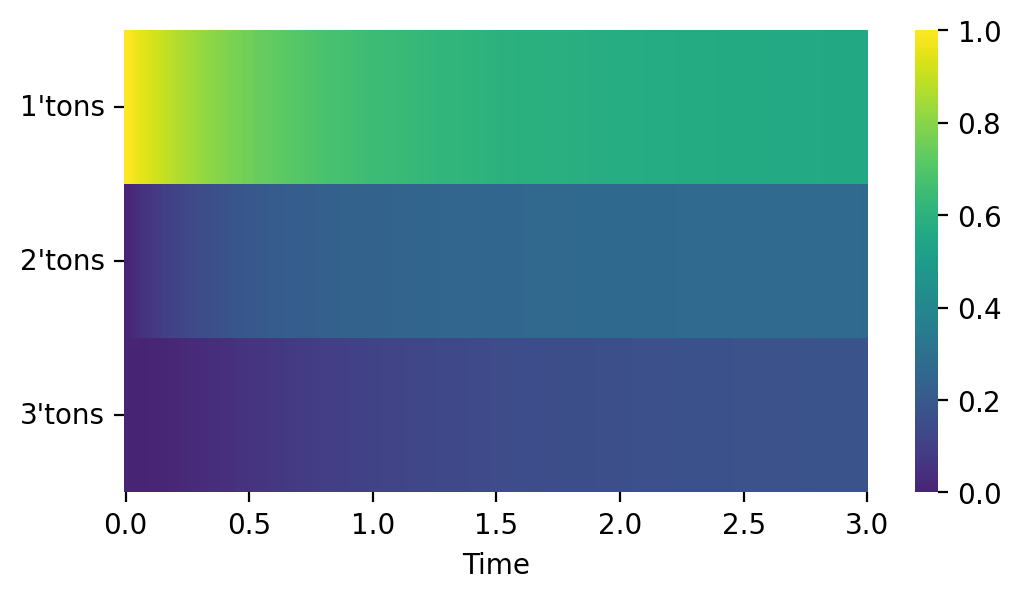

<Figure size 500x370 with 0 Axes>

In [7]:
@np.vectorize
def brlen_accumulated(i, t):
    acc_occ = graph.accumulated_occupancy(t)*reward_matrix[i]
    return np.sum(acc_occ).item()

times = np.linspace(0, 3, 301)
tons = list(range(nr_samples-1))
X, Y = np.meshgrid(tons, times, indexing='ij')
result = brlen_accumulated(X, Y)
col_sums = result.sum(axis=0)
result = result / col_sums[np.newaxis, :]
result = pd.DataFrame(
    result, 
    columns=times, 
    index=[f"{i+1}'tons" for i in range(nr_samples-1)]
    )

with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(figsize=(6,3))
    ax = sns.heatmap(result, cmap='iridis', ax=ax, 
                    xticklabels = 50 
                    )
    ax.set_xlabel('Time')
    plt.yticks(rotation=0)
    plt.show()

## Moments of epoch-wise time homogeneous phase-type distributions

[8.726427931363645, 173.4223204898314, 5233.840746862072, 209923.8992478049, 10506328.513422351]


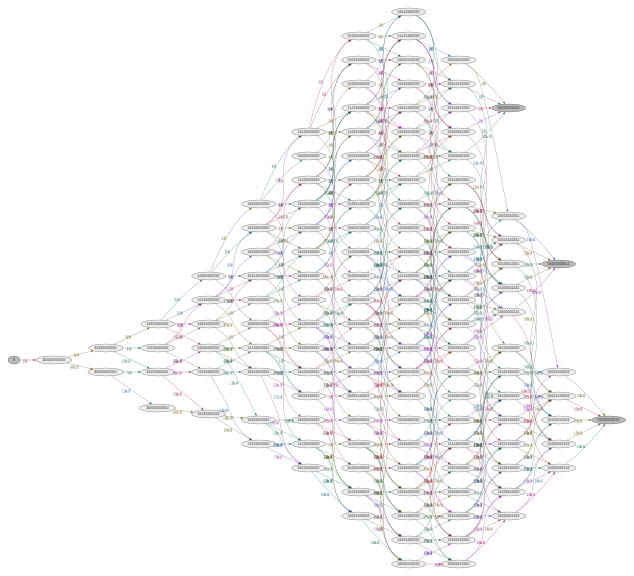

In [8]:
from phasic import Graph, StateIndexer, PropertySet, Property
import numpy as np
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)


# nr_samples = 2
# epochs = [0, 1, 2]
# pop_sizes = [1, 5, 10]

# nr_samples = 10
# epochs = [0, 1, 2]
# pop_sizes = [1, 5, 10]

# # epochs = [0, 1, 2, 3, 4, 5]
# # pop_sizes = [1, 5, 10, 2, 4, 1]


# indexer = StateIndexer(
#       lineages=[Property('ton', min_value=1, max_value=nr_samples)], 
#       slots=['epoch'] 
#   )

def coalescent_1param(state, epochs=None, epoch_idx=None, indexer=None):    
    transitions = []

    epoch_idx = int(epoch_idx)

    if state[indexer.epoch] != epoch_idx:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1:
            continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        k = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1
        coeff = np.zeros(len(epochs)+1) # +1 to have a slot for transitions between epochs
        coeff[epoch_idx] = state[i]*(state[j]-same)/(1+same)
        # print(epoch_idx, coeff)

        transitions.append([new, coeff])
        # transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])

    return transitions


def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    
    epoch = epochs[epoch_idx]
    stop_probs = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid='ignore'):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length()-1):

        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue        
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state = vertex.state()

        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx        
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(len(epochs)+1) # +1 to have a slot for transitions between epochs
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)


nr_samples = 10
epochs = [0, 1, 2]
pop_sizes = [1, 5, 10]

# epochs = [0, 1, 2, 3, 4, 5]
# pop_sizes = [1, 5, 10, 2, 4, 1]


indexer = StateIndexer(
      lineages=[Property('ton', min_value=1, max_value=nr_samples)], 
      slots=['epoch'] 
  )

ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = nr_samples

graph = Graph(coalescent_1param, 
              ipv=ipv,
              epochs=epochs,
              epoch_idx=0,
              indexer=indexer,
              )
graph.update_weights([1/size for size in pop_sizes] + [1])

for epoch_idx in range(1, len(epochs)):
    graph.update_weights([1/size for size in pop_sizes] + [1])
    add_epoch(graph, coalescent_1param, epochs, epoch_idx, indexer)

graph.update_weights([1/size for size in pop_sizes] + [1])

print(graph.moments(5))
graph.plot(size=(12, 8), wrap=False, max_nodes=300)

## Check

In [9]:
janek = np.array([8.807791589074768, 177.8449395799212, 5388.12207361224, 
                   216313.46645481227, 10829024.877199283])


In [10]:
mine = graph.moments(5)
(mine - janek) / janek

array([-0.00923769, -0.02486784, -0.0286336 , -0.02953846, -0.02979921])

## SFS

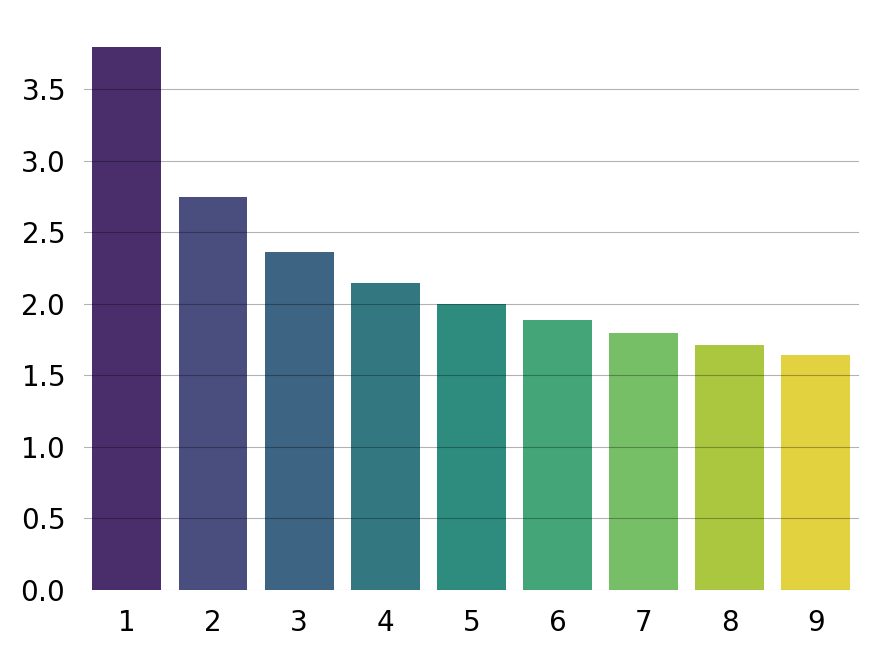

In [11]:
# Get states and remove epoch label column
state_mat = graph.states()
rewards = state_mat[:, :-1]  # Remove last column (epoch labels)

# Compute site frequency spectrum
x = np.arange(1, nr_samples)
sfs = np.zeros(nr_samples - 1)
for i in range(nr_samples - 1):
    reward_vec = rewards[:, i]
    transformed_graph = graph.reward_transform(reward_vec)
    sfs[i] = transformed_graph.moments(1)[0]

sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette='iridis', legend=False);

## Comparing to the exact results of Pool and Nielsen for pairwise coelescence time

In [12]:
def exp_coal(g, N):
    """
    Compute expected coalescence time in epoch
    N is the number of diploid invididuals
    g is the number of generations spanned by the epoch
    """
    # return 2*N - (g * np.exp(-g/(2*N))) / (1 - np.exp(-g/(2*N)))
    return N - (g * np.exp(-g/(N))) / (1 - np.exp(-g/(N)))

def epoch(demog, h, i):
    "Recursively compute expected coalescence time across all epoches"
    g, N = demog[i]
    N *= h
    if i == len(demog)-1:
    #     return 2*N
    # return (1-np.exp(-g/(2*N))) * exp_coal(g, N) + np.exp(-g/(2*N)) * (g + epoch(demog, h, i+1))
        return N
    return (1-np.exp(-g/(N))) * exp_coal(g, N) + np.exp(-g/(N)) * (g + epoch(demog, h, i+1))

def pool_nielsen(gens, Ne, h):
    """
    Compute expected coalescence time in units of 2N
    Ne is the a list/series of Ne in the epoch.
    gens is the a list/series of generation at which an each epoch begins (the last epoch lasts forever)
    h is the relative population size, 0.75 for chrX.
    """
    epochs = list()
    for i in range(len(gens)):
        if i == 0:
            epochs.append((gens[i+1], Ne[i]))
        elif i == len(gens)-1:
            epochs.append((None, Ne[i]))    
        else:
            epochs.append((gens[i+1] - gens[i], Ne[i]))
    return epoch(epochs, h, 0)

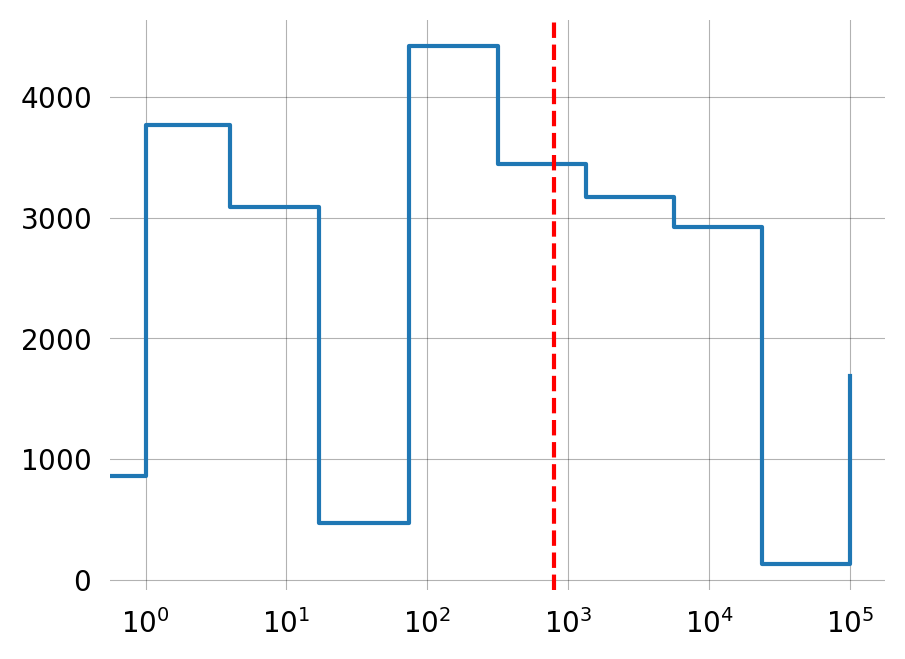

In [13]:
n = 10
sampledemog_data = pd.DataFrame(dict(years=[0]+np.logspace(0, 5, n-1, dtype=int, base=10).tolist(),
                               Ne=np.random.randint(1, 5_000, size=n),
                               population=['pop']*n
                              ))

sampledemog_data.sort_values('years', inplace=True)

gen_time = 30
exp_coal_time = pool_nielsen(gens=sampledemog_data.years / gen_time, 
                               Ne=sampledemog_data.Ne,
                               h=1)
# pool_nielsen(gens, Ne, 0.75)
plt.step(sampledemog_data.years, sampledemog_data.Ne, where='post')
plt.gca().set_xscale('log')
plt.gca().axvline(exp_coal_time, color='red', linestyle='--')
plt.show()

## Phase-type distributions

In the example below, we let it represetn a recombination rate in an ARG so we can compute the probability that two loci separated by a recombination distance $θ$ are represented by the same tree in our sample. I.e., that no recombination has occurred on the branches of the tree at locus1 one at any of the positions between locus one and two.

In [14]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

## Matrix-based computation

In [15]:
S = np.array([[-6, 6, 0, 0], 
              [0, -3, 1, 2], 
              [0, 0, -1, 0], 
              [0, 0, 0, -1]], dtype=float)
alpha = np.array([1, 0, 0, 0], dtype=float)  # starting state
n = len(alpha)

In [16]:
theta = 0.5

s0 = -S @ np.ones(n)
laplace_result = np.linalg.solve(theta * np.eye(n) - S, s0)
print(laplace_result)

[0.52747253 0.57142857 0.66666667 0.66666667]


In [17]:
S_new = S - theta * np.eye(n)
print("Modified S matrix:")
print(S_new)

Modified S matrix:
[[-6.5  6.   0.   0. ]
 [ 0.  -3.5  1.   2. ]
 [ 0.   0.  -1.5  0. ]
 [ 0.   0.   0.  -1.5]]


## Laplace transformation as graph operations

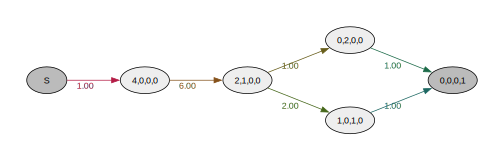

In [18]:
graph = Graph(coalescent)
graph.plot()

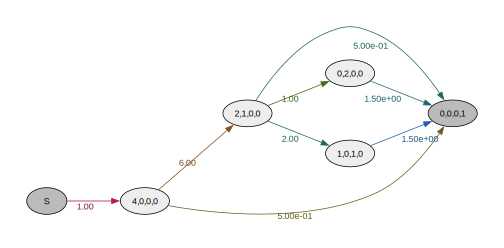

In [19]:
lap_graph = graph.laplace_transform(theta)
lap_graph.plot()

In [20]:
theta = 0.5
rewards = graph.absorbing_state_rewards()
lap_graph.expected_waiting_time(rewards)

[0.5274725274725275,
 0.5274725274725275,
 0.5714285714285714,
 0.6666666666666666,
 0.6666666666666666,
 0.0]

## Expectation and Variance 

In [21]:
lap_graph.expectation(rewards), lap_graph.variance(rewards)

(0.5274725274725275, 0.4250694360584471)

In [22]:
lap_graph.moments(5)

[0.945054945054945,
 1.4462021494988528,
 3.064427903940041,
 8.376088953712031,
 28.218036661593196]

### PDF

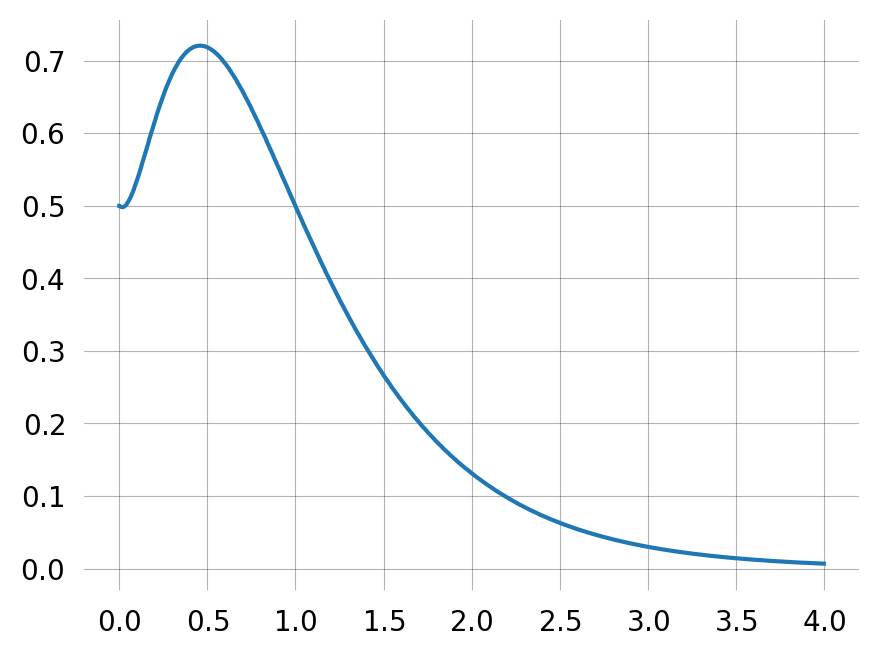

In [23]:
time = np.arange(0, 4, 0.001)
pdf = lap_graph.pdf(time)
plt.plot(time, pdf)
plt.show()

## Joint probability

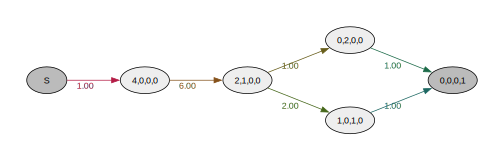

In [24]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, state[i]*(state[j]-same)/(1+same)])
    return transitions

graph = Graph(coalescent)
graph.plot()

In [25]:
mutation_rate = 0.1
joint_prob_graph = graph.joint_prob_graph(indexer, tot_reward_limit=2, mutation_rate=mutation_rate)
joint_prob_graph.vertices_length()

39

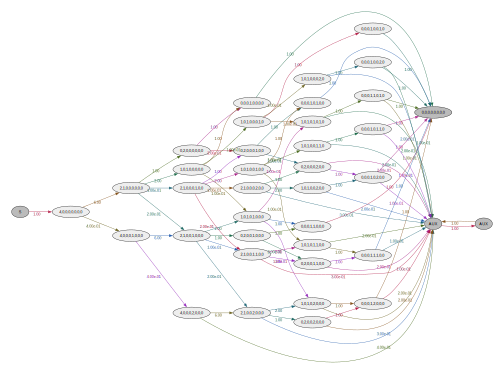

In [26]:
joint_prob_graph.plot(nodesep=0.3)

In [27]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,0.710227
18,0,1,0,0,0.060979
20,1,0,0,0,0.126890
23,0,0,1,0,0.039457
30,0,2,0,0,0.007658
31,2,0,0,0,0.014744
32,1,0,1,0,0.010394
33,0,0,2,0,0.002989
34,1,1,0,0,0.009097


In [28]:
(1 - joint_prob_table['prob'].sum()).item()

0.016476095092311294

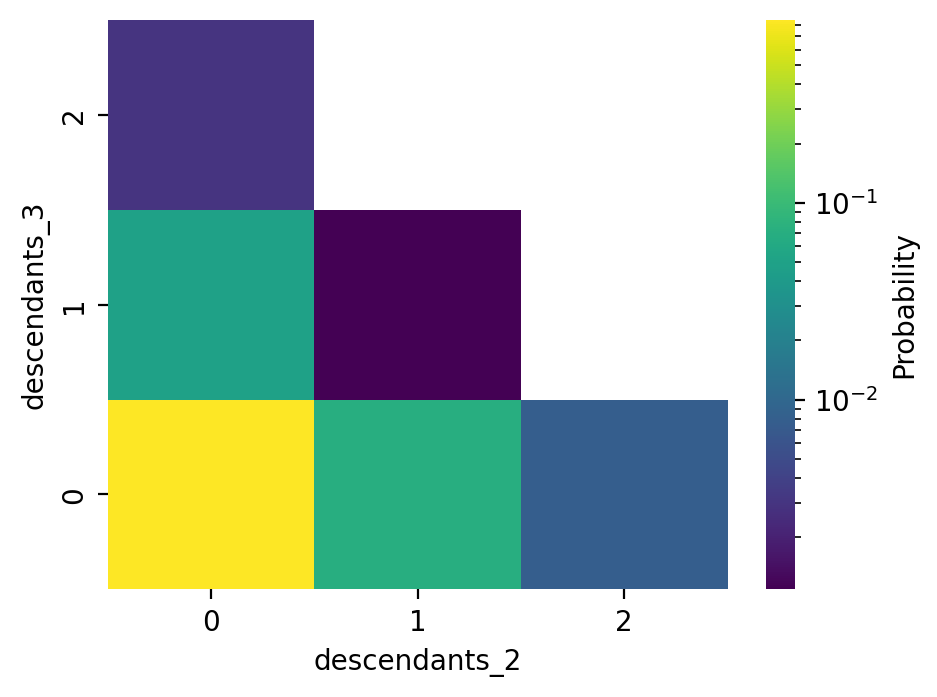

In [29]:
ton_pair = ['descendants_2', 'descendants_3']
plot_df = joint_prob_table[ton_pair + ['prob']].groupby(ton_pair).sum().reset_index()   
plot_df = plot_df.pivot(index=ton_pair[1], columns=ton_pair[0], values='prob')

with vscode_theme(style='ticks'):
    ax = sns.heatmap(
        plot_df,
        cmap='viridis',
        cbar_kws={'label': 'Probability'},
        xticklabels=1,
        yticklabels=1,
        norm=LogNorm(),
    )
    ax.set(xlabel=ton_pair[0], ylabel=ton_pair[1])
    ax.invert_yaxis()
plt.show()

In [30]:
joint_prob_graph.expectation()

inf

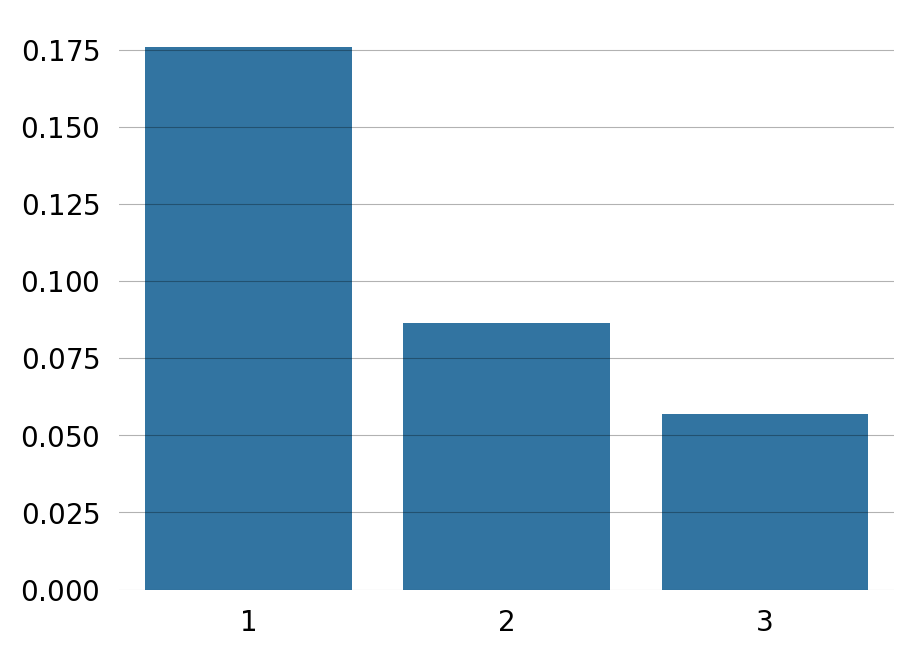

In [31]:
tons = np.arange(1, nr_samples)
marginals = [np.sum(joint_prob_table[f'descendants_{t}'] * joint_prob_table['prob']) for t in tons]
sns.barplot(x=tons, y=marginals);
plt.show()